In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from collections import defaultdict

# Test Data

#### Path to your CSV files, assuming they follow a consistent naming pattern

In [2]:
file_paths = glob.glob('/home/chad/Desktop/scawels/dataset/electricitymap_data/test/*.csv')

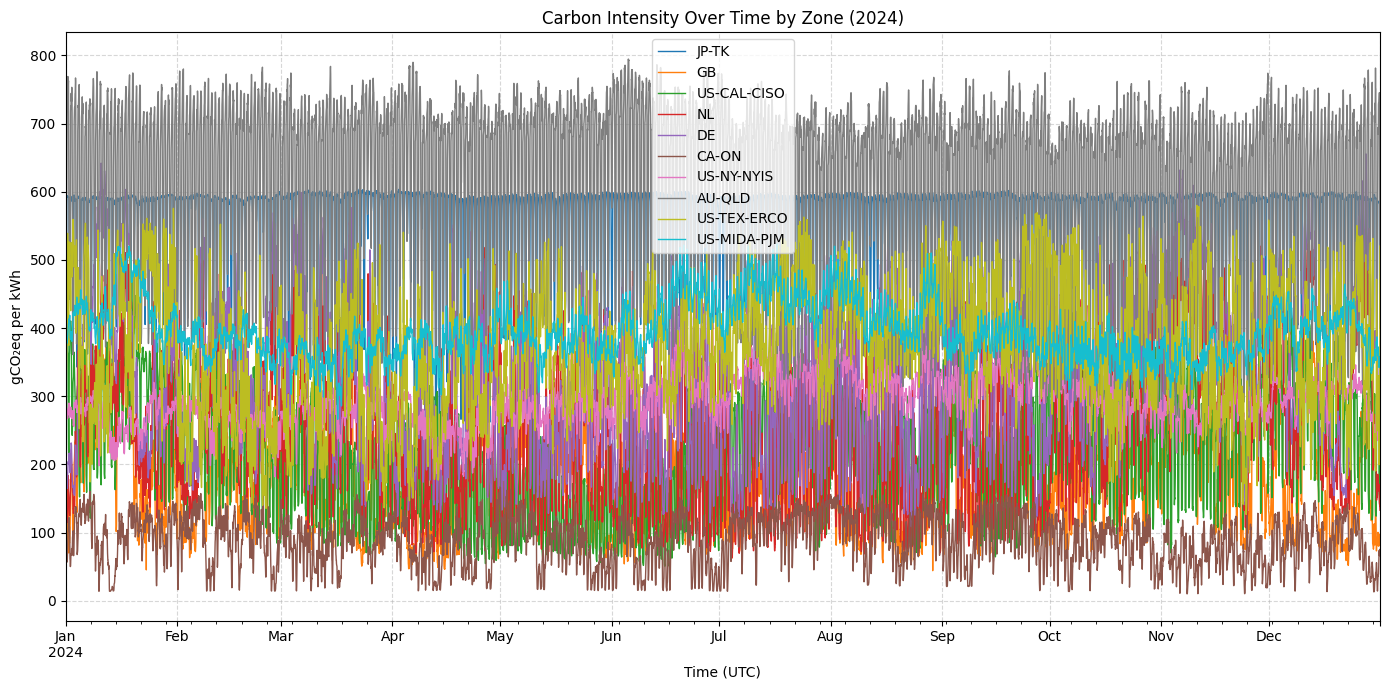

In [3]:
plt.figure(figsize=(14, 7))
for file_path in file_paths:
    # Extract zone name from filename, e.g., 'FR' from 'FR_2024_hourly.csv'
    zone_name = os.path.basename(file_path).split('_')[0]
    
    # Load data
    df = pd.read_csv(file_path, parse_dates=['Datetime (UTC)'])
    df.set_index('Datetime (UTC)', inplace=True)
    
    # Plot Life cycle carbon intensity
    if 'Carbon intensity gCO₂eq/kWh (Life cycle)' in df.columns:
        df['Carbon intensity gCO₂eq/kWh (Life cycle)'].plot(label=f'{zone_name}', linewidth=1)

# Plot formatting
plt.title('Carbon Intensity Over Time by Zone (2024)')
plt.xlabel('Time (UTC)')
plt.ylabel('gCO₂eq per kWh')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

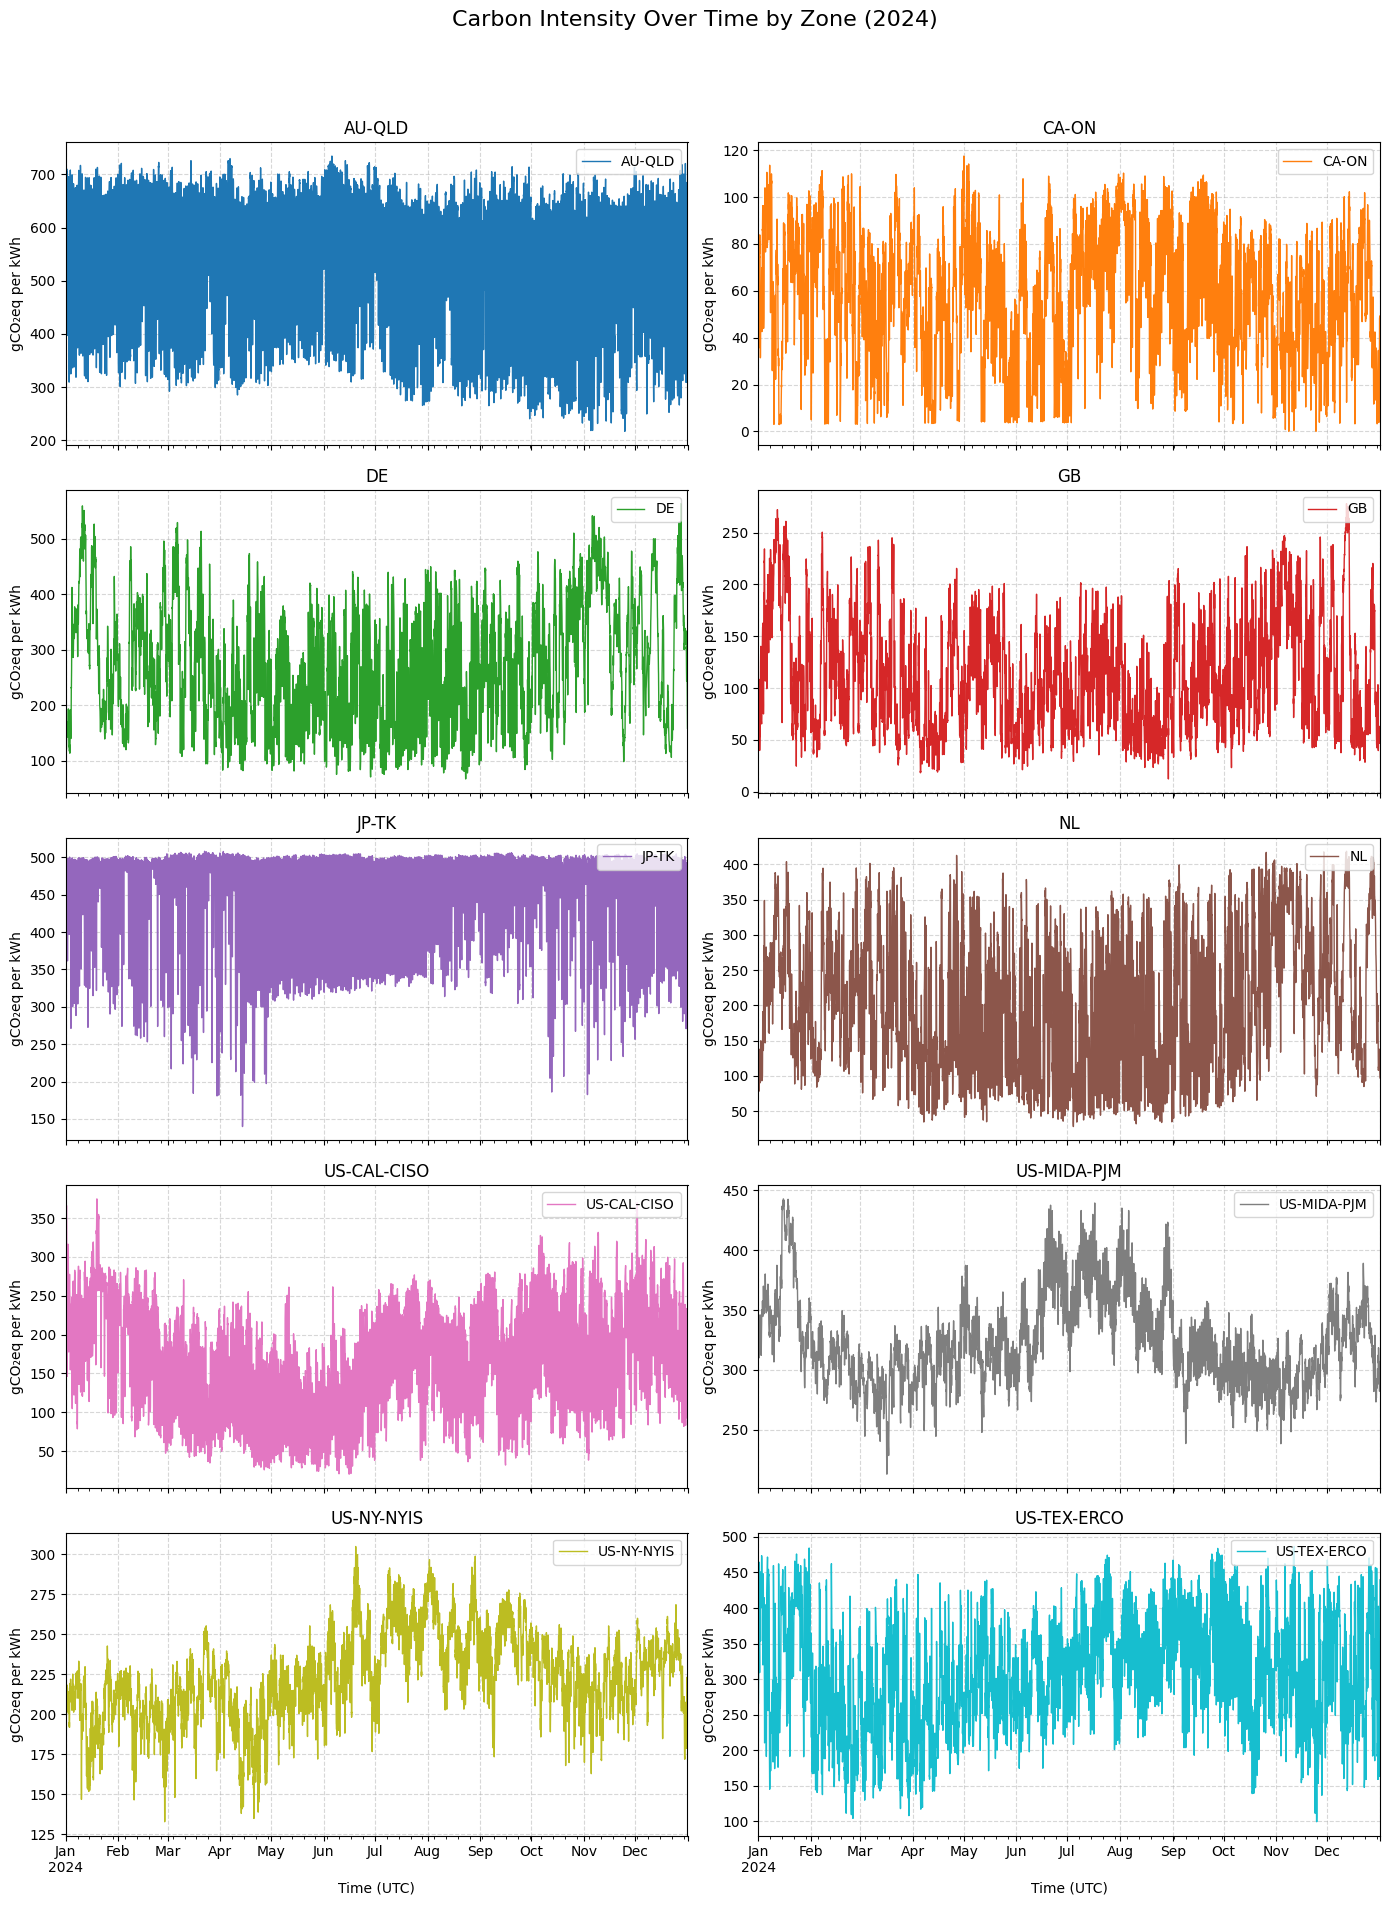

In [3]:
# Sort file_paths alphabetically by zone_name for consistent order
file_paths.sort(key=lambda x: os.path.basename(x).split('_')[0])

# Create a 5x2 grid of subplots
fig, axs = plt.subplots(5, 2, figsize=(14, 20), sharex=True)
fig.suptitle('Carbon Intensity Over Time by Zone (2024)', fontsize=16)

for i, file_path in enumerate(file_paths):
    # Extract zone name from filename, e.g., 'FR' from 'FR_2024_hourly.csv'
    zone_name = os.path.basename(file_path).split('_')[0]
    
    # Load data
    df = pd.read_csv(file_path, parse_dates=['Datetime (UTC)'])
    df.set_index('Datetime (UTC)', inplace=True)
    
    # Select the axis for this subplot
    ax = axs[i // 2, i % 2]
    
    # Plot Life cycle carbon intensity
    if 'Carbon intensity gCO₂eq/kWh (direct)' in df.columns:
        df['Carbon intensity gCO₂eq/kWh (direct)'].plot(ax=ax, label=zone_name, linewidth=1, color=f'C{i}')
    
    # Subplot formatting
    ax.set_title(zone_name)
    ax.set_ylabel('gCO₂eq per kWh')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

# Set common xlabel for the bottom row
for ax in axs[-1, :]:
    ax.set_xlabel('Time (UTC)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust for suptitle
plt.show()

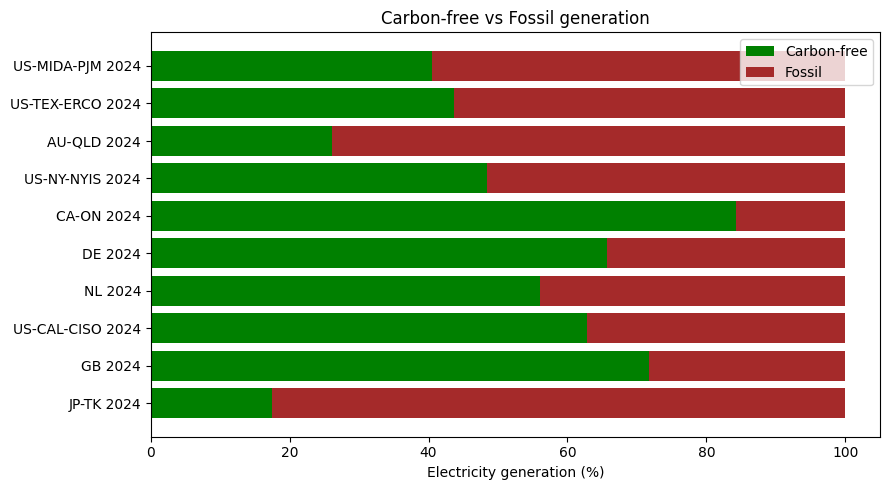

In [15]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Collect files
file_paths = glob.glob('/home/chad/Desktop/scawels/dataset/electricitymap_data/test/*.csv')

# Group by zone
zone_files = defaultdict(list)
for path in file_paths:
    zone = os.path.basename(path).split('_')[0]  # e.g., US-NY-NYIS
    year = os.path.basename(path).split('_')[1]  # e.g., 2022
    zone_files[f"{zone} {year}"].append(path)

# Store average CFE and fossil %
records = []
for zone_year, paths in zone_files.items():
    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    if "Carbon-free energy percentage (CFE%)" in df.columns:
        avg_cfe = df["Carbon-free energy percentage (CFE%)"].mean()
        fossil = 100 - avg_cfe
        records.append({"RegionYear": zone_year, "CFE%": avg_cfe, "Fossil%": fossil})

df_cfe = pd.DataFrame(records).set_index("RegionYear")

# Plot stacked bars
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(df_cfe.index, df_cfe["CFE%"], label="Carbon-free", color="green")
ax.barh(df_cfe.index, df_cfe["Fossil%"], left=df_cfe["CFE%"], label="Fossil", color="brown")

ax.set_xlabel("Electricity generation (%)")
ax.set_title("Carbon-free vs Fossil generation")
ax.legend()
plt.tight_layout()
plt.show()


# Train Data

In [4]:
file_paths = glob.glob('/home/chad/Desktop/scawels/dataset/electricitymap_data/train/*.csv')

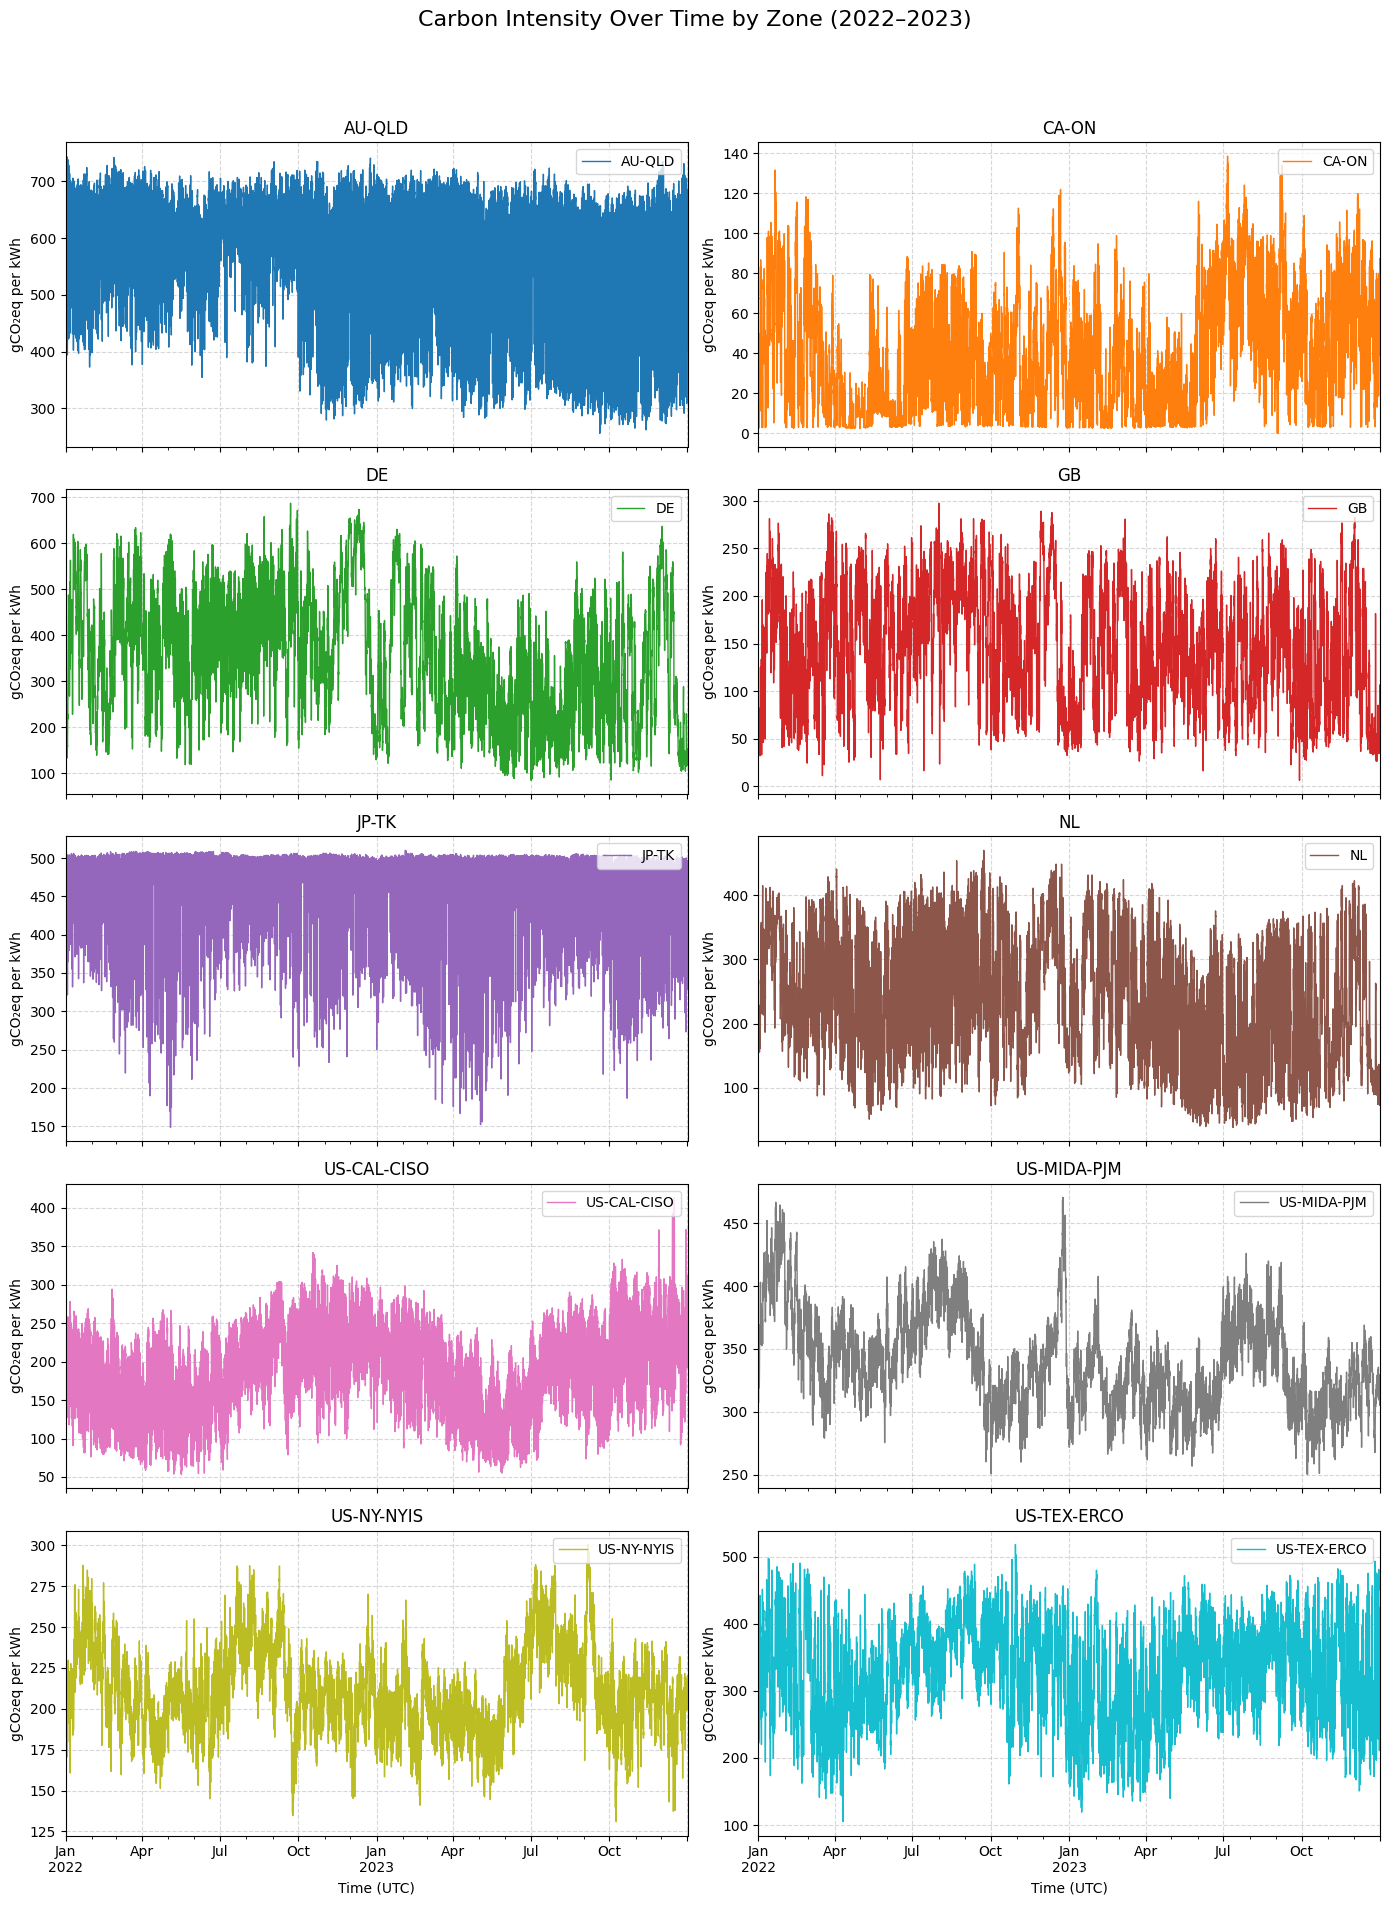

In [5]:
# Group file paths by zone (e.g., 'US-NY-NYIS')
zone_files = defaultdict(list)
for path in file_paths:
    zone = os.path.basename(path).split('_')[0]  # Assumes filenames like 'ZONE_YYYY_hourly.csv'
    zone_files[zone].append(path)

# Sort zone names alphabetically for consistent plot order
sorted_zones = sorted(zone_files.keys())

# Create a 5x2 grid of subplots
fig, axs = plt.subplots(5, 2, figsize=(14, 20), sharex=True)
fig.suptitle('Carbon Intensity Over Time by Zone (2022–2023)', fontsize=16)

for i, zone_name in enumerate(sorted_zones):
    # Concatenate all years of data for this zone
    dfs = []
    for file_path in sorted(zone_files[zone_name]):
        df = pd.read_csv(file_path, parse_dates=['Datetime (UTC)'])
        dfs.append(df)
    df_combined = pd.concat(dfs, ignore_index=True)
    df_combined.set_index('Datetime (UTC)', inplace=True)

    # Select the axis for this subplot
    ax = axs[i // 2, i % 2]

    # Plot Life cycle carbon intensity
    if 'Carbon intensity gCO₂eq/kWh (direct)' in df_combined.columns:
        df_combined['Carbon intensity gCO₂eq/kWh (direct)'].plot(
            ax=ax, label=zone_name, linewidth=1, color=f'C{i}'
        )

    # Subplot formatting
    ax.set_title(zone_name)
    ax.set_ylabel('gCO₂eq per kWh')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

# Set common xlabel for the bottom row
for ax in axs[-1, :]:
    ax.set_xlabel('Time (UTC)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout for suptitle
plt.show()

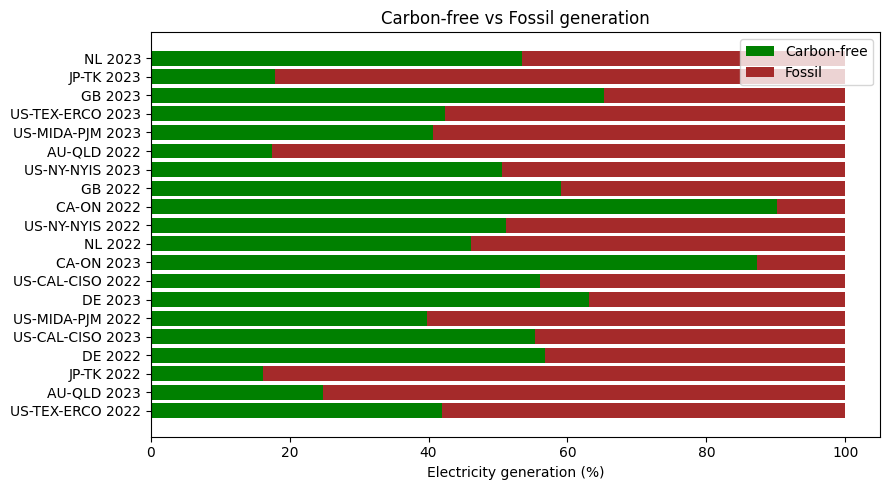

In [14]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Collect files
file_paths = glob.glob('/home/chad/Desktop/scawels/dataset/electricitymap_data/train/*.csv')

# Group by zone
zone_files = defaultdict(list)
for path in file_paths:
    zone = os.path.basename(path).split('_')[0]  # e.g., US-NY-NYIS
    year = os.path.basename(path).split('_')[1]  # e.g., 2022
    zone_files[f"{zone} {year}"].append(path)

# Store average CFE and fossil %
records = []
for zone_year, paths in zone_files.items():
    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    if "Carbon-free energy percentage (CFE%)" in df.columns:
        avg_cfe = df["Carbon-free energy percentage (CFE%)"].mean()
        fossil = 100 - avg_cfe
        records.append({"RegionYear": zone_year, "CFE%": avg_cfe, "Fossil%": fossil})

df_cfe = pd.DataFrame(records).set_index("RegionYear")

# Plot stacked bars
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(df_cfe.index, df_cfe["CFE%"], label="Carbon-free", color="green")
ax.barh(df_cfe.index, df_cfe["Fossil%"], left=df_cfe["CFE%"], label="Fossil", color="brown")

ax.set_xlabel("Electricity generation (%)")
ax.set_title("Carbon-free vs Fossil generation")
ax.legend()
plt.tight_layout()
plt.show()
